# Классификация проектов капитального строительства

Файл адаптирован под работу в yandex datasphere, в которой по умолчанию предлагается окружение с python 3.10. 
В связи с чем необходимо устанавливать предыдущие согласованные версии библиотек.

Структура файла:
- Установка необходимых библиотек
- Блок импорта библиотек
- Функции обработки данных - загрузка, удаление пустых значений, очистка от нерелевантных частей имен проекта, токенизация, лемматизация.
- Функция получения данных для обучения
- Функции векторизации: векторизация с помощью Word2Vec, векторизация с помощью sentence_transformer, 
добавление вектора ключевых слов к любому вектору.
- Функции поиска оптимальных параметров с помощью GridSearchCV и RandomSearch.
- Классификация - при создании обучающей и тестовой выборок передается конкретный набор векторов, в зависимости от этого дальнейшие эксперименты проводятся на этих векторах.

In [120]:
# install libraries

%pip install numpy==1.23.5
%pip install typer==0.9.4
%pip install torch==2.0.1
%pip install transformers==4.34.0
%pip install sentence-transformers==3.0.0
%pip install spacy==3.5.4
%pip install tensorflow==2.12.0
%pip install torchtext==0.15.2
%pip install nltk==3.7
%pip install scipy==1.15.3
%pip install gensim==4.4.0
%pip install xgboost==1.7.6
%pip install catboost
%pip install pymorphy3
%pip install lightgbm --config-settings=cmake.define.USE_GPU=ON
%pip install seaborn

%pip check

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ------------------------------------ 294.9/294.9 kB 423.6 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


No broken requirements found.
Note: you may need to restart the kernel to use updated packages.


In [121]:
import os
# Из-за предупреждений от библиотеки transformer
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import io
import re
import string

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models.word2vec import Word2Vec
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool
from pymorphy3 import MorphAnalyzer
from lightgbm import LGBMClassifier
import nltk
from nltk.corpus import stopwords

## Функции загрузки и предобработки данных

In [102]:
Labels = [
    "Автомобильные дороги",
    "Водоотведение",
    "Водопроводы",
    "Газоны, дорожки, площадки, фонтаны",
    "Газопроводы",
    "Горные выработки",
    "Железнодорожные пути",
    "Заводы, фабрики, индустриальные парки",
    "Здания",
    "Инженерное обеспечение территорий",
    "Инфраструктура наземного электротранспорта",
    "Линии электропередачи",
    "Метрополитены",
    "Мосты и тоннели",
    "Наружное освещение",
    "Нефтепроводы",
    "Сооружения",
    "Теплопроводы",
    "Технологические установки",
]

ColumnNames = ["id", "project_name", "label"]

def load_labeled_data_raw(path):
    labeled_dataframes = [
        pd.read_csv(f"{path}//{label}.csv", names=ColumnNames, header=0)
        for label in Labels
    ]
    result_df = pd.concat(labeled_dataframes)
    result_df["project_name"] = result_df["project_name"].str.strip('"')
    return result_df

def remove_not_required(df):
    not_required_mask = df['project_name'] != 'Не требуется'
    return df.loc[not_required_mask].dropna()

def split_by_string(text, string):
    split_parts = re.split(string, text, flags=re.IGNORECASE)
    if (len(split_parts) > 1):
        return split_parts[0].strip()
    else:
        return text

# Удаление адресов необходимо, поскольку они добавляют семантического шума.
# Вектора проектов в одном городе будут ближе друг к другу, чем вектора проектов в разных городах.
def remove_adress_substring (df):
    # Порядок важен: "Почтовый адрес" обязателен и стоит в конце, 
    # но помимо этого проект может завершаться на "по адресу" или "адрес объекта" в любом регистре или просто "расположенный в ..." 
    df['project_name'] = df['project_name'].apply(lambda text : split_by_string(text, 'почтовый адрес:'))
    df['project_name'] = df['project_name'].apply(lambda text : split_by_string(text, 'по адресу'))
    df['project_name'] = df['project_name'].apply(lambda text : split_by_string(text, 'адрес'))
    df['project_name'] = df['project_name'].apply(lambda text : split_by_string(text, 'расположен'))
    return df

def load_labeled_data(path):
    df = load_labeled_data_raw(path)
    df = remove_not_required(df)
    df = remove_adress_substring(df)
    return df

def load_unlabeled_data_raw(path):
    return pd.read_csv(path, sep=";", encoding="utf-8", names=["id", "project_name"], header=0)

def load_unlabeled_data(path):
    df = load_unlabeled_data_raw(path)
    df = remove_not_required(df)
    df = remove_adress_substring(df)
    return df

tokenizer = nltk.tokenize.RegexpTokenizer(r'\w+')
pymorphy_analyzer = MorphAnalyzer()
lemmas_cache = {}
punctuation = set(string.punctuation)
punctuation.add('``')
punctuation.add('\'\'')
stopwords_set = set(stopwords.words('russian'))

def tokenize_lemmatize(text):
    text = text.replace('\\', '/')
    text = text.replace('ул.', 'улица')
    text= re.sub('[()]', '', text)

    result = []
    words = tokenizer.tokenize(text)
    
    for word in words:
        if word in punctuation:
            pass
        if word in stopwords_set:
            continue
        if word in lemmas_cache:
            result.append(lemmas_cache[word])
        else:
            lemma = word
            # Считаем такое слово аббревиатурой
            if not word.isupper():
                parse_result = pymorphy_analyzer.parse(word.lower())
                lemma = parse_result[0].normal_form
                
            lemmas_cache[word] = lemma
            result.append(lemma)
    return result

def tokenize_lemmatize_series(series):
    return series.apply(tokenize_lemmatize).dropna()

# Здесь получаем словарь вида {{labelName, [[keyword1], [keyword2, keyword3]]}} ключевых слов и выражений 
# Этот словарь содержит экспертной знание о том какие аббревиатуры или устойыивые выражения вероятно относят проект
# к той или иной категории.
# Важно использовать один и тот же способ токенизации и лемматизации для текстов и для устойчивых выражений.
# Иначе не найдутся вхождения выражений в лемматизированном тексте.
def make_keywords_dict(lines):
    result = {label: [] for label in Labels}
    
    for line in lines:
        if line == '\n':
            continue
        extract_quoted_part_re = r'"([^"]*)"'
        matches = re.findall(extract_quoted_part_re, line)
        if len(matches) == 2:
            key = matches[1]
            expression = matches[0]
            normalized_keywords = tokenize_lemmatize(expression)
            if normalized_keywords not in result[key]:
                result[key].append(normalized_keywords)
        else:
            print(f"Ошибка: ожидается 2 строки в кавычках, найдено {len(matches)}: {line}")    
    return result

def make_keywords_dict_from_file(text_path):
    with io.open(text_path, mode = 'r', encoding='utf-8') as file:
        lines = file.readlines()

    return make_keywords_dict(lines)

## Функция визуализации матрицы ошибок

In [134]:
def make_cm_plot(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap='Blues'
                #,xticklabels=Labels
                ,yticklabels=Labels
                )
    plt.ylabel('Истинные метки')
    plt.xlabel('Предсказанные метки')
    plt.title('Confusion Matrix')
    plt.show()

## Функции разделения данных на выборки

In [103]:
def data_train_test_split(data, labels):
    assert len(data) == len(
        labels
    ), "Размеры списков данных и результатов разметки не совпадают"
    le = LabelEncoder()
    le.fit(labels)
    y = le.transform(labels)
    return train_test_split(data, y, test_size=0.2, random_state=42)

## Функции векторизации

### Векторизация с помощью Word2Vec

In [104]:
def vectorize_with_word2vec(texts, model, vector_size):
    result = []
    for text in texts:
        text_vector = []
        for word in tokenize_lemmatize(text):
            if word in model.wv:
                text_vector.append(model.wv[word])

        if len(text_vector):
            text_vector = np.average(text_vector, axis=0)
        else:
            text_vector = np.zeros(vector_size)
        result.append(text_vector)
    return result

### Векторизация с помощью Sentence transformer

In [105]:
# Вернет матрицу размера (len(sentences, 1024)
def vectorize_with_sentence_transformer(model_name, texts):
    model = SentenceTransformer(model_name)
    return model.encode(texts.to_numpy())

### Добавление векторов основанных на включении аббревиатур и устойчивых выражений

In [106]:
def tokenized_text_contains_keywords(text_words, keywords_list):
    keywords_list_len = len(keywords_list)
    text_len = len(text_words)

    if keywords_list_len > text_len:
        return False

    for i in range(text_len - keywords_list_len + 1):
        if text_words[i : i + keywords_list_len] == keywords_list:
            return True
    return False

# Предполагаем, что тексты не лемматизированы, но из них удалены нерелевантные части (адреса). 
# Для Word2Vec в принципе можно было бы использовать предобработанные
# и сократить время на токенизацию их здесь. Но для других способов векторизации (sbert) мы можем не иметь рпедобработанных текстов.
# Чтобы не усложнять код будем принимать "сырые" тексты и предобрадатывать здесь.
def make_keywords_vector(text, keywords_dict):
    vector_size = len(Labels)
    assert vector_size == len(keywords_dict.keys()), "Неожиданный размер словаря ключевых слов"

    text_words = tokenize_lemmatize(text)

    result = np.zeros(vector_size)
    for label, label_keywords_list in keywords_dict.items():
        label_index = Labels.index(label)
        for keyword_list in label_keywords_list:
            if tokenized_text_contains_keywords(text_words, keyword_list):
                result[label_index] += 1
    return result


def concat_keywords_vector(texts, vectors, keywords_dict):
    assert len(texts) == len(vectors), "Размеры списков данных и векторов не совпадают"
    
    test_result = []
    result = []
    for text, vector in zip(texts, vectors):
        keywords_vector = make_keywords_vector(text, keywords_dict)
        result_vector = np.concatenate([vector, keywords_vector])
        
        result.append(result_vector)
        test_result.append([text, keywords_vector])

    scaler = StandardScaler()
    result = scaler.fit_transform(result)
    return result, test_result
    


## Функции оптимизации с помощью Grid search и Random search

In [107]:
def find_best_model_gs(X_train, y_train, estimator, param_grid, n_jobs = -1):
    grid_search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring="accuracy",
        cv=3,
        # Этим управляем для CatBoost - при использовании -1 (занять все ядра) он формирует столько параллельных процессов на CPU, 
        # что для них не хватает памяти на GPU
        n_jobs=n_jobs
    )
    grid_search.fit(X_train, y_train)
    return grid_search.best_estimator_, grid_search.best_params_

def find_best_model_rs(X_train, y_train, estimator, param_dist, n_iter, n_jobs = -1):
    random_search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring="accuracy",
        cv=3,
        # Этим управляем для CatBoost - при использовании -1 (занять все ядра) он формирует столько параллельных процессов на CPU, 
        # что для них не хватает памяти на GPU
        n_jobs=n_jobs
    )
    random_search.fit(X_train, y_train)
    return random_search.best_estimator_, random_search.best_params_

## Классификация проектов

### Загрузим данные для обучения

In [108]:
df = load_labeled_data("../Data/Reestr/Размеченные")
#df

### Загрузим весь корпус, проанализируем его

In [109]:
lemmas_cache.clear()
# Векторизация Word2Vec
# Для векторизации будем использовать весь корпус слов
df_unlabeled = load_unlabeled_data(f'../Data/Reestr/Реестр 2022-2024 clean.csv')
df_unlabeled_lemmatized = tokenize_lemmatize_series(df_unlabeled['project_name'])
#df_unlabeled_lemmatized = tokenize_lemmatize_series(df_unlabeled['project_name'][30000:40000])
#df_unlabeled

#### Распределение длин текстов

Text(0.5, 1.0, 'Гистограмма длин имен проектов')

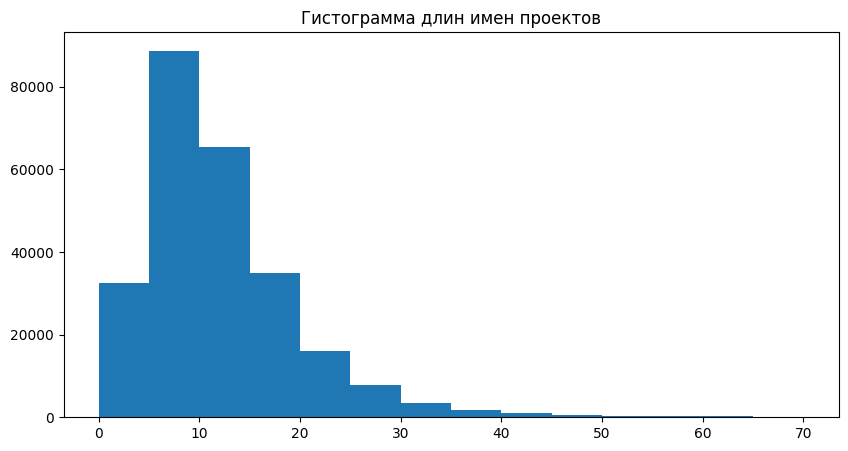

In [110]:
words_count_hist_figure = plt.figure(figsize=(10, 5))
words_count_series = df_unlabeled_lemmatized.transform(lambda words:len(words))
words_hist = words_count_hist_figure.add_subplot(1, 1, 1)
words_hist.hist(words_count_series, bins=14, range=(0, 70))
words_hist.set_title("Гистограмма длин имен проектов")

#### Оценим лексическое разнообразие

In [111]:
ttr_series = df_unlabeled_lemmatized.apply(lambda tokens: len(set(tokens)) / len(tokens) if tokens else 0)
np.average(ttr_series)

0.9595645944517777

#### Посмотрим количество уникальных слов и наиболее частые слова

In [99]:
def get_words_frequency(bow, features):
    word_usage = bow.sum(axis=0)
    words_usage_dict = np.stack((np.array(word_usage[0]).ravel(), features), axis=1)
    indices = np.argsort(-words_usage_dict[:, 0])
    return words_usage_dict[indices]

def get_most_popular_words(bow, features, count):
    return get_words_frequency(bow, features)[:count-1]

def get_most_unique_words(bow, features, count):
    return get_words_frequency(bow, features)[-count:]

# Тексты уже токенизированы и предобработаны - сделаем заглушки чтобы не обрабатывать их повторно
count_vectorizer = CountVectorizer(ngram_range=(1, 1), tokenizer=lambda x: x, preprocessor=lambda x: x)
bow_matrix = count_vectorizer.fit_transform(df_unlabeled_lemmatized)
most_popular_words = get_most_popular_words(bow_matrix, count_vectorizer.get_feature_names_out(), 100)
most_unique_words = get_most_unique_words(bow_matrix, count_vectorizer.get_feature_names_out(), 100)
len(count_vectorizer.get_feature_names_out())

c:\Edu\ML\Diploma\.venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


70979

### Векторизация

In [112]:
word2vec_model = Word2Vec(df_unlabeled_lemmatized, workers=8, vector_size=300, min_count=3, window=5, epochs=15,)
word2vec_vectors = vectorize_with_word2vec(df['project_name'], word2vec_model, 300)

In [113]:
# Векторизация с помощью SentenceTransformer с использованием модели 'sberbank-ai/sbert_large_nlu_ru'
sbert_vectors = vectorize_with_sentence_transformer(
    "sberbank-ai/sbert_large_nlu_ru", df["project_name"]
)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [114]:
keywords_dict = make_keywords_dict_from_file('../Data/keywords.txt')
#keywords_dict

In [ ]:
vectors_with_keywords, test = concat_keywords_vector(df['project_name'], word2vec_vectors, keywords_dict)
#np.shape(vectors_with_keywords)

### Разделeние на тестовую и обучающую выборки

In [115]:
# Здесь регулируем какие вектора будут использоваться в моделях
X_train, X_test, y_train, y_test = data_train_test_split(sbert_vectors, df["label"])

### Логистическая регрессия

#### Параметры модели

In [116]:
log_reg_param_grid = {
        "C": [0.05, 0.1, 1, 10, 50],
        "penalty": ["l1", "l2", 'elasticnet'],
        "solver": ["liblinear", "saga"],
        "max_iter": [500, 1000]}

log_reg_test_param_grid = {
        "C": [50],
        "penalty": ["l2"],
        "solver": ["saga"],
        "max_iter": [1000]}

 #### Обучение модели

In [117]:
# Выбор лучшей модели
lr_initial_model = LogisticRegression(random_state=42)
lr_best_model, lr_best_params = find_best_model_gs(X_train, y_train, lr_initial_model, log_reg_test_param_grid)
#lr_best_model, lr_best_params = find_best_model_rs(X_train, y_train, lr_initial_model, log_reg_param_grid, 30)
#lr_best_model.fit(X_train, y_train)
y_pred = lr_best_model.predict(X_test)

print("Лучшие параметры: ", lr_best_params)
print("Точность:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Лучшие параметры:  {'C': 50, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'saga'}
Точность: 0.8736842105263158
              precision    recall  f1-score   support

           0       0.82      0.95      0.88        19
           1       0.89      0.94      0.92        18
           2       0.89      0.77      0.83        22
           3       0.95      0.88      0.91        24
           4       1.00      0.91      0.95        23
           5       0.96      0.92      0.94        25
           6       0.89      1.00      0.94        17
           7       0.93      0.81      0.87        16
           8       0.64      0.82      0.72        11
           9       0.83      0.87      0.85        23
          10       1.00      0.91      0.95        11
          11       0.89      0.80      0.84        20
          12       0.79      0.95      0.86        20
          13       0.95      0.82      0.88        22
          14       1.00      1.00      1.00        25
          15       0.85 

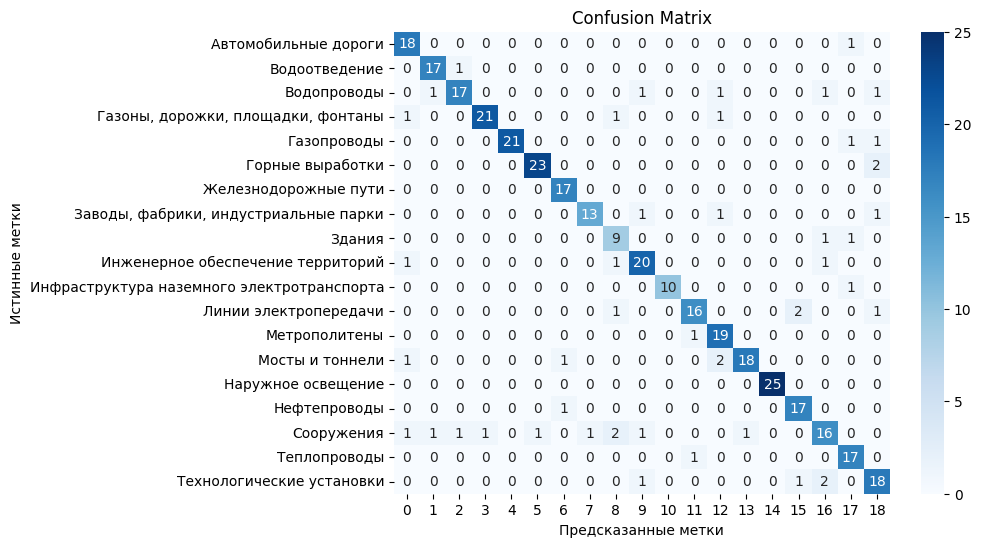

In [135]:
make_cm_plot(y_test, y_pred)

### XGBoost

#### Параметры модели

In [ ]:
xgb_test_param_grid = {"n_estimators": [300], "max_depth": [3], "learning_rate": [0.1], "reg_lambda": [0.01], "reg_alpha": [0.1], "subsample" : [0.7]}

xgb_param_grid = {
    "n_estimators": [100, 150, 200, 300, 400],
    "max_depth": [3, 4, 6, 8],
    "learning_rate": [0.05, 0.1, 0.2, 0.3],
    # доля случайных взятых в обучение сэмплов
    "subsample" : [0.5, 0.6, 0.7, 0.8, 0.9],
    # регуляризации
    "reg_alpha": [0, 0.01, 0.1, 1, 5],
    "reg_lambda": [0, 0.01, 0.1, 1, 5]
}

#### Обучение модели

In [ ]:
xgb_initial_model = XGBClassifier(n_jobs=-1, eval_metric="logloss", tree_method="gpu_hist", random_state=42)
xgb_best_model, xgb_best_params = find_best_model_gs(X_train, y_train, xgb_initial_model, xgb_test_param_grid)
#xgb_best_model, xgb_best_params = find_best_model_rs(X_train, y_train, xgb_initial_model, xgb_param_grid, 40)
xgb_best_model.fit(X_train, y_train)
y_pred = xgb_best_model.predict(X_test)

print("Лучшие параметры: ", xgb_best_params)
print("Точность:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

### CatBoost

#### Параметры модели

In [ ]:
cb_param_grid = {
        "learning_rate": [0.01, 0.05, 0.1, 0.5],
        "depth": [3, 4, 6, 8],
        "l2_leaf_reg": [1, 2, 4, 8, 10],
        "iterations": [50, 100, 300, 500],
        # борьба с шумом, когда выбирается признак по которому происходит разбиение - этот параметр добавляет некоторый шум
        # чтобы, как я понимаю, нивелировать шум в данных. После этого исскуственного зашумления уже делается оценка метрики качества для разбиения.
        "random_strength": [0.5, 1, 2.0],
        # условно тоже что и subsample, но динамически подстраивающееся под
        # ошибку на конкретном объекте. Т.е. управление вероятностью выбора сэмпла из выборки.
        "bagging_temperature": [0.1, 0.5, 0.8, 1.0, 1.2]}

cb_test_param_grid = {"learning_rate": [0.1]}

#### Обучение модели

In [ ]:
cb_initial_model = CatBoostClassifier(logging_level='Silent', devices='0', gpu_ram_part=0.3, loss_function='MultiClass', task_type="GPU", random_seed=42)
#cb_best_model, cb_best_params = find_best_model_rs(X_train, y_train, cb_initial_model, cb_test_param_grid)
cb_best_model, cb_best_params = find_best_model_rs(X_train, y_train, cb_initial_model, cb_param_grid, 40, n_jobs = 3)

#cb_best_model.fit(X_train, y_train)
y_pred = cb_best_model.predict(X_test)

print("Лучшие параметры: ", cb_best_params)
print("Точность:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

### Light GBM

#### Параметры модели

In [14]:
lgbm_param_grid = {
    'learning_rate': [0.01, 0.02, 0.05, 0.1, 0.3],
    'n_estimators': [100, 500, 1000],
    'num_leaves': [10, 20, 30, 40],
    'max_depth': [3, 5, 6],
    'reg_alpha': [0, 1, 2, 5, 10],
    'reg_lambda': [0, 1, 2, 5, 10],
    "subsample" : [0.5, 0.6, 0.7, 0.8, 0.9],
    'boosting_type': ['gbdt', 'dart']
}

lgbm_param_grid_test = {
    'learning_rate': [0.1],
    'n_estimators': [100],
    'num_leaves': [10],
    'max_depth': [3],
    'reg_alpha': [0],
    'reg_lambda': [0],
    "subsample" : [0.9],
    'boosting_type': ['gbdt']
}

In [ ]:
lgbm_initial_model = LGBMClassifier(objective='multiclass', num_class=len(Labels), metric='multi_logloss', random_state=42)
#lgbm_best_model, lgbm_best_params = find_best_model_rs(X_train, y_train, lgbm_initial_model, cb_param_grid, 40, n_jobs = 3)
lgbm_best_model, lgbm_best_params = find_best_model_rs(X_train, y_train, lgbm_initial_model, lgbm_param_grid_test, 1, n_jobs = 3)

y_pred = lgbm_best_model.predict(X_test)

print("Лучшие параметры: ", lgbm_best_params)
print("Точность:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

: 